
# Project 2 — Dropout Classifier

This notebook implements the full assignment pipeline:

1. **Data pre-processing & cleaning**
2. **Correlation analysis** (feature↔feature, feature↔label) with visuals and short discussion
3. **Train 4 models** (probabilistic, distance-based, tree-based, ensemble)
4. **k-fold cross validation** (accuracy mean±std) and **confusion matrices**
5. **Pick best model** and **feature importances**
6. **Save the best model** as `best_model.pkl` and features.json




## 0. Import Required Libraries

In this step, we import all the essential Python libraries needed for data analysis, visualization, and machine learning.

In [1]:

# Import standard warning and serialization libraries
import warnings, pickle, json

warnings.filterwarnings("ignore") # Suppress unnecessary warning messages


# Import data analysis librarie

import numpy as np # Numerical operations
import pandas as pd # Data manipulation and cleaning
import matplotlib.pyplot as plt # Data visualization

# Import tools for machine learning model training and evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Import machine learning algorithms
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

print("All libraries imported successfully.")



All libraries imported successfully.


## 1. Data loading & cleaning

In this step, we load the dataset and check if it has been read correctly.


In [2]:
# Specify the file path for the dataset
DATA_PATH = "data.csv"

# Load dataset
df = pd.read_csv(DATA_PATH, sep=";")

# Clean column names by removing unwanted characters, tab and space
df.columns = [c.strip().replace('\t','').replace('\u200b','') for c in df.columns]

# Print the number of rows and columns to understand the dataset size
print("Shape:", df.shape)

# display the first 3 rows of the dataframe
display(df.head()) 

 # show the information about columns and data types
df.info()

Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

## 2. Define target (Dropout=1, else 0)

### Preparing the Target and Feature Data

In this step, we clean the Target column and convert it into numbers so the model can use it.<br>

- 1 means the student dropped out.<br>
- 0 means the student did not drop out.<br>

Then we separate the dataset into:<br>

- X : all input features<br>
- Y : the target variable (dropout or not)

In [3]:

# Clean the 'Target' column by removing extra spaces
df['Target'] = df['Target'].astype(str).str.strip()

# Create target variable (1 = dropout, 0 = not-dropout)
y = (df['Target'].str.lower() == 'dropout').astype(int)

# Create feature set by removing the target column
X = df.drop(columns=['Target'])

# Show how many students dropped out vs. did not drop out
print("Class balance (0=not-dropout, 1=dropout):")
display(y.value_counts(normalize=True).rename('ratio'))


Class balance (0=not-dropout, 1=dropout):


Target
0    0.678797
1    0.321203
Name: ratio, dtype: float64

### Handle missing values

In this step, we check if the dataset has any missing values. <br>

If some values are missing, we fill the numeric columns with their median values.

In [4]:
# Count how many missing and NaN values are in each column and sort them from most to least
na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts[na_counts>0].head(10))

# Find all numeric columns in the dataset
num_cols = X.select_dtypes(include=[np.number]).columns

# Replace missing values in numeric columns with the median value of each column
X[num_cols] = X[num_cols].fillna(X[num_cols].median())


Series([], dtype: int64)

## 3. Correlation analysis (feature↔feature, feature↔label)

In this step, we Checks how each feature is related to the target variable (dropout) and to other features.<br>

- first we calculates the correlation between all features and the dropout label.<br>
- It selects the top 20 features that have the strongest relationship with dropout<br>
- A vertical bar chart shows which features are most related to student dropout.<br>
- A heatmap shows how these top features are related to each other.<br>



,corr_with_label
Age at enrollment,0.254215
Debtor,0.229407
Gender,0.203983
Application mode,0.198458
Marital status,0.093712
Curricular units 2nd sem (without evaluations),0.079901
Previous qualification (grade),-0.078208
Daytime/evening attendance,-0.080499
Curricular units 1st sem (evaluations),-0.090125
Admission grade,-0.095806


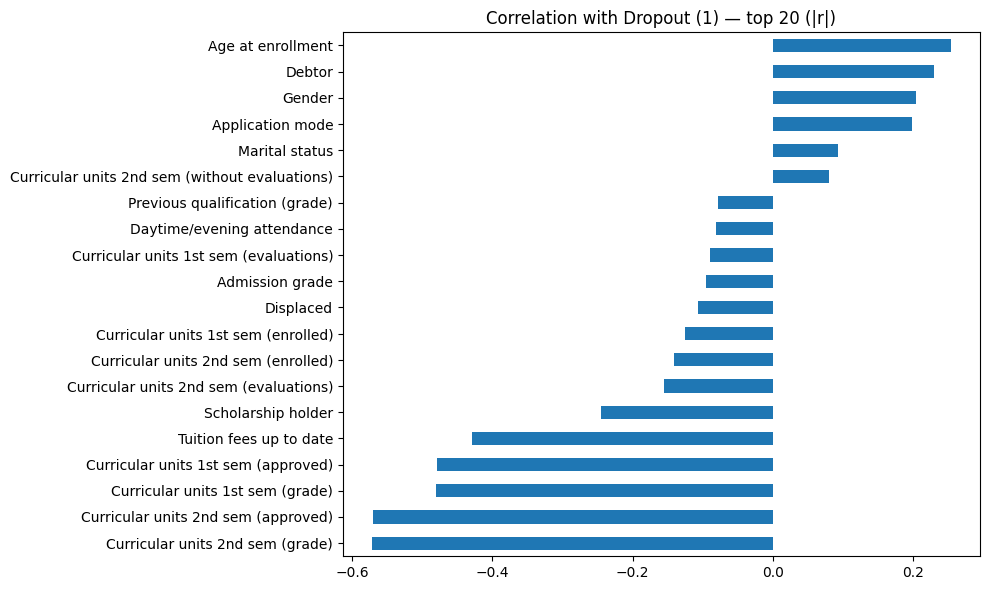

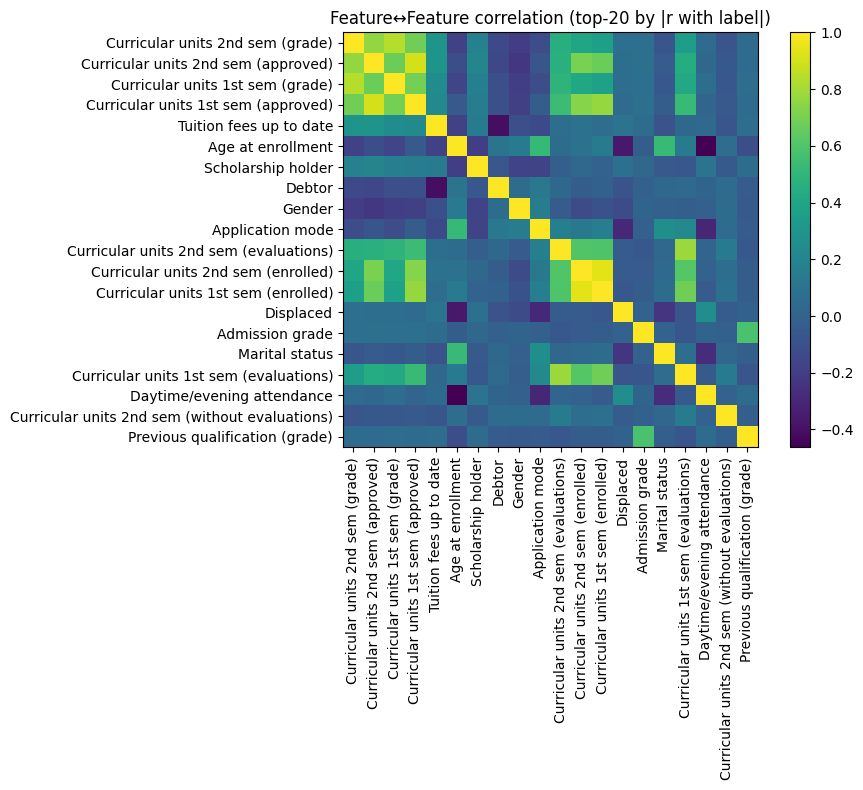

In [5]:

# Calculate correlation between features using Pearson method
corr_ff = X.corr()

# Calculate correlation between each feature and the target (dropout)
feat_to_label = X.apply(lambda col: np.corrcoef(col, y)[0,1])

# get top 20  features most related to dropout
top20 = feat_to_label.abs().sort_values(ascending=False).head(20).index
display(feat_to_label[top20].sort_values(ascending=False).to_frame("corr_with_label")) # Display the correlation values for these top 20 features

# Plot a horizontal bar chart of the top 20 features
plt.figure(figsize=(10,6))
feat_to_label[top20].sort_values().plot(kind='barh')
plt.title("Correlation with Dropout (1) — top 20 (|r|)")
plt.tight_layout(); plt.show()

# Create a heatmap showing how the top 20 features correlate with each other
subset = corr_ff.loc[top20, top20]
plt.figure(figsize=(10,8))
plt.imshow(subset, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(top20)), top20, rotation=90)
plt.yticks(range(len(top20)), top20)
plt.title("Feature↔Feature correlation (top-20 by |r with label|)")
plt.tight_layout(); plt.show()


## 4. Models: probabilistic, distance-based, tree-based, ensemble

In this step, we define four different machine learning models to compare their performance:<br>

1. GaussianNB: A probabilistic model.<br>

2. KNN: A distance-based model that uses the nearest neighbors.<br>

3. RandomForest: A tree-based model using multiple decision trees.<br>

4. AdaBoost: An ensemble model that combines many weak learners.<br>

In [6]:
# Define different machine learning models for comparison

# 1. Gaussian Naive Bayes (probabilistic)
model_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", GaussianNB())
])

# 2. K-Nearest Neighbors (distance-based)
model_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=7))
])

# 3. Random Forest (tree-based)
model_rf = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

# 4. AdaBoost (ensemble)
model_ab = AdaBoostClassifier(
    n_estimators=150,
    random_state=42
)

# Combine all models into a dictionary for easy access
models = {
    "GaussianNB (probabilistic)": model_nb,
    "KNN (distance-based)": model_knn,
    "RandomForest (tree-based)": model_rf,
    "AdaBoost (ensemble)": model_ab
}

# Display the model names
list(models.keys())


['GaussianNB (probabilistic)',
 'KNN (distance-based)',
 'RandomForest (tree-based)',
 'AdaBoost (ensemble)']

## 5. Evaluation: 5-fold Stratified CV (accuracy mean±std) + confusion matrices

In this step, we test all models using 5-fold stratified cross-validation, where the data is split into five parts and each model is trained and tested five times for fair and reliable results. <br>

- we calculate the the average accuracy and standard deviation for each model.<br>
- Creates a confusion matrix to show how well the model predicts dropout and non-dropout cases.<br>
- Prints the results so we can see which model performs best and how each one makes errors.<br>


In [7]:

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #The data is split into 5 parts and Each model is trained on 4 folds and tested on the remaining one.

# Define a function to evaluate a model
def cv_evaluate(model, X_values, y_values, cv): # Trains and tests a given model across all 5 folds.

    accs, cm_total = [], np.zeros((2,2), dtype=int)
    
    # Loop over CV folds
    for tr, te in cv.split(X_values, y_values):

        model.fit(X_values[tr], y_values[tr]) # Train the model on training folds

        y_pred = model.predict(X_values[te]) # Predict on test data folds

        accs.append(accuracy_score(y_values[te], y_pred))   # Store accuracy for this fold

        cm_total += confusion_matrix(y_values[te], y_pred, labels=[1,0])    # Add confusion matrix of this fold (labels fixed as [1,0])

    # Return mean/std accuracy and total confusion matrix over all folds
    return float(np.mean(accs)), float(np.std(accs)), cm_total 

# Convert DataFrame to numpy arrays for faster indexing
X_vals, y_vals = X.values, y.values


# Evaluate all models and collect results
results, matrices = {}, {}
for name, mdl in models.items(): # Trains and tests each model across all 5 folds.
    m, s, cm = cv_evaluate(mdl, X_vals, y_vals, cv) # Runs the cv_evaluate function
    results[name] = (m, s) #Saves results mean accuracy, standard deviation,
    matrices[name] = cm # store summed confusion matrix


# Display the accuracy results for all models
res_df = pd.DataFrame({k: {"accuracy_mean": v[0], "accuracy_std": v[1]} for k,v in results.items()}).T
display(res_df.sort_values("accuracy_mean", ascending=False))

# Print confusion matrix results
def read_cm(cm):
    
    # labels=[1,0] used above → rows: true Dropout, true Not-Dropout
    tp, fn = cm[0,0], cm[0,1]
    fp, tn = cm[1,0], cm[1,1]
    return tp, fn, fp, tn

for name, cm in matrices.items():
    tp, fn, fp, tn = read_cm(cm)
    print(f"{name:28s}  TP={tp:4d}  FN={fn:4d}  FP={fp:4d}  TN={tn:4d}")


,accuracy_mean,accuracy_std
RandomForest (tree-based),0.876132,0.007352
AdaBoost (ensemble),0.871157,0.002780
KNN (distance-based),0.836120,0.006609
GaussianNB (probabilistic),0.819848,0.008912


GaussianNB (probabilistic)    TP=1019  FN= 402  FP= 395  TN=2608
KNN (distance-based)          TP= 824  FN= 597  FP= 128  TN=2875
RandomForest (tree-based)     TP=1023  FN= 398  FP= 150  TN=2853
AdaBoost (ensemble)           TP=1043  FN= 378  FP= 192  TN=2811


## 6. Pick best model & feature importances

In this Step we find and analyze the best-performing model after testing all models. <br>

1. First we selects the best model — the one with the highest average accuracy from cross-validation.<br>

2. we trains that model again on the entire dataset to make full use of all data.<br>

3. It then finds which features (student attributes) are most important for predicting dropouts.<br>
   
   - For tree-based models (like Random Forest or AdaBoost), feature importance comes built-in.<br>

   - For other models (like Naive Bayes or KNN), it uses permutation importance, which checks how much accuracy drops when a feature is shuffled.<br>

4. Finally, we plots the top 15 most important features in a bar chart.<br>



Best model: RandomForest (tree-based) → (0.8761318608277732, 0.0073519798402803625)


Curricular units 2nd sem (approved)       0.158989
Curricular units 2nd sem (grade)          0.119153
Curricular units 1st sem (approved)       0.091395
Curricular units 1st sem (grade)          0.067145
Tuition fees up to date                   0.065485
Age at enrollment                         0.042306
Admission grade                           0.039195
Curricular units 2nd sem (evaluations)    0.033774
Previous qualification (grade)            0.033286
Course                                    0.029508
Curricular units 1st sem (evaluations)    0.027897
Father's occupation                       0.023783
Mother's occupation                       0.022297
Curricular units 2nd sem (enrolled)       0.021269
GDP                                       0.020347
dtype: float64

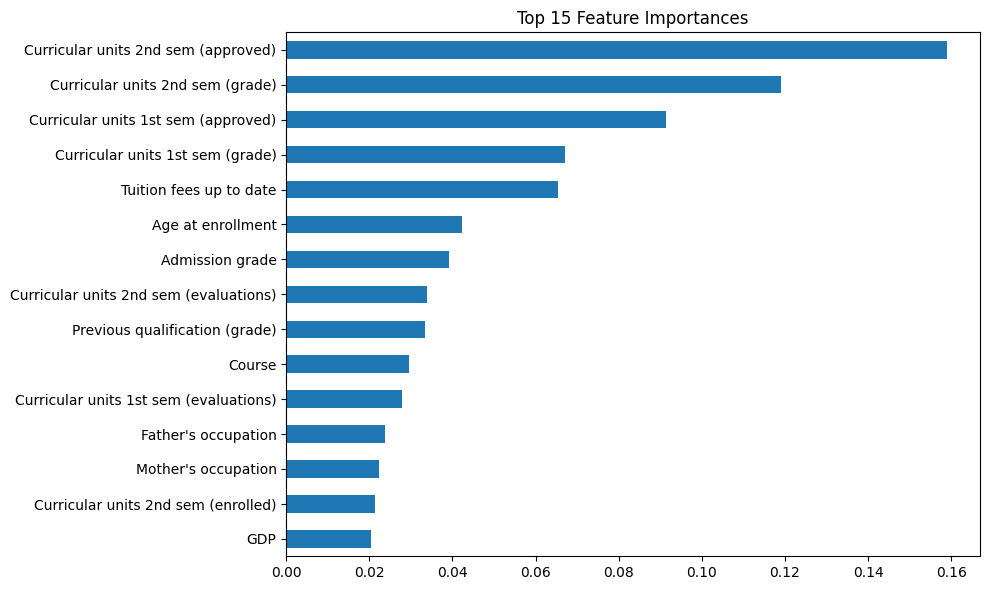

In [8]:

# Find the model with the highest mean accuracy
best_name = max(results, key=lambda k: results[k][0])

# Get the best model from the models dictionary
best_model = models[best_name]

# Train the best model on the full dataset
best_model.fit(X_vals, y_vals)
print("Best model:", best_name, "→", results[best_name])

# Try to get feature importance (works for tree-based and boosting models)
try:
    importances = best_model.feature_importances_ 
    fi = pd.Series(importances, index=X.columns).sort_values(ascending=False) # Get feature importances
    display(fi.head(15)) # Display top 15 important features

    # Plot top 15 important features
    fi.head(15).sort_values().plot(kind='barh', figsize=(10,6))
    plt.title("Top 15 Feature Importances")
    plt.tight_layout(); plt.show()

# If the model does not have 'feature_importances_' (like Naive Bayes or KNN), use permutation importance instead
except AttributeError:
    from sklearn.inspection import permutation_importance
    r = permutation_importance(best_model, X_vals, y_vals, n_repeats=10, random_state=42, n_jobs=-1) # Compute permutation importance
    fi = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False) # Get permutation importances
    display(fi.head(15)) # Display top 15 permutation importances

    # Plot top 15 permutation importances
    fi.head(15).sort_values().plot(kind='barh', figsize=(10,6))
    plt.title("Top 15 Permutation Importances")
    plt.tight_layout(); plt.show()


## 7. Save model (`best_model.pkl`) and `features.json`

- In this step, we save the best trained model to a file named best_model.pkl so it can be used later without retraining. <br>
- We also save the feature names in a features.json file to ensure consistency when making future predictions.<br>
- Finally, we reload the saved model to confirm that it was stored correctly.<br>

In [9]:

# Save the best trained model to a file named 'best_model.pkl'
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save feature list for safe inference
feature_names = list(X.columns)
with open("features.json", "w") as f:
    json.dump(feature_names, f)

# Reload the saved model to check that it was saved correctly
with open("best_model.pkl", "rb") as f:
    loaded = pickle.load(f)
print("Reloaded OK:", type(loaded))


Reloaded OK: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
